# Caso D · 02 ETL bronce → plata IAQ + poblar captia_metadata

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Transformar el CSV In-Gauge a `captia_point` y poblar `captia_point_meta` para que las tareas Flux de downsampling funcionen.


## 2. Qué se aprende

- Mapping completo In-Gauge → CAPTIA.
- Diferencia continuo vs on-change.
- Cómo poblar el catálogo de variables.
- Routing a `state_events`.


## 3. Contexto del caso de uso

Sin `captia_point_meta` poblado, los buckets `_1m`, `_15m`, `_1h` quedan vacíos; el modelo del notebook 04 fallará.


## 4. Relación con CENTINELA+

El catálogo es por dominio (no por aula): poblar una vez por `domain_id` es suficiente.


## 5. Relación con Medallion

Bronce → plata + metadata.


## 6. Datos de entrada

`ingauge_aula01_mock.csv`.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Two outputs: telemetría `.lp` y metadata `.lp` para `captia_metadata`.


## 9. Carga de datos o mock

Cargamos y reformulamos largo.


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "ingauge_aula01_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"])
mapping = {
    "Indoor_CO2": ("co2", "telemetry"),
    "Indoor_Temp": ("temperature_01", "telemetry"),
    "Indoor_Hum": ("relative_humidity_01", "telemetry"),
    "Indoor_Noise": ("avg_sound_level", "telemetry"),
    "Indoor_Lux": ("luminosity", "telemetry"),
    "People_Count": ("people_count", "telemetry"),
    "Occupied": ("occupancy", "telemetry"),
    "CoolingState": ("ac_state", "state_events"),
}
print(mapping)


{'Indoor_CO2': ('co2', 'telemetry'), 'Indoor_Temp': ('temperature_01', 'telemetry'), 'Indoor_Hum': ('relative_humidity_01', 'telemetry'), 'Indoor_Noise': ('avg_sound_level', 'telemetry'), 'Indoor_Lux': ('luminosity', 'telemetry'), 'People_Count': ('people_count', 'telemetry'), 'Occupied': ('occupancy', 'telemetry'), 'CoolingState': ('ac_state', 'state_events')}


## 10. Exploración paso a paso

Para cada columna del CSV producimos una serie larga; `state_events` se filtra a transiciones.


In [3]:
def emit_lp_telemetry(df, csv_col, captia_var, asset="AULA01"):
    serie = df[["timestamp", csv_col]].dropna()
    for _, row in serie.iterrows():
        ts_ns = int(pd.Timestamp(row["timestamp"]).value)
        yield build_line_protocol(
            measurement=MEASUREMENT_TELEMETRY,
            tags={
                "captia_env": "dev", "domain_id": "bms_classrooms",
                "site_id": "ies_simarro", "asset_id": asset, "variable": captia_var,
            },
            fields={"value": float(row[csv_col])},
            timestamp_ns=ts_ns,
        )

def emit_lp_state(df, csv_col, captia_var, asset="AULA01"):
    serie = df[["timestamp", csv_col]].dropna().copy()
    serie["chg"] = serie[csv_col].diff().fillna(serie[csv_col]).abs() > 0
    for _, row in serie[serie["chg"]].iterrows():
        ts_ns = int(pd.Timestamp(row["timestamp"]).value)
        yield (
            f"captia_point,captia_env=dev,domain_id=bms_classrooms,"
            f"site_id=ies_simarro,asset_id={asset},variable={captia_var} "
            f"value={float(row[csv_col])} {ts_ns}"
        )


## 11. Transformación bronce → plata

Generamos los dos ficheros (sample 200 filas para clase).


In [4]:
out_dir = ROOT / "output" / "case_D"
out_dir.mkdir(parents=True, exist_ok=True)
sample = df.head(200)

telem_lines, state_lines = [], []
for csv_col, (captia_var, kind) in mapping.items():
    if kind == "telemetry":
        telem_lines.extend(emit_lp_telemetry(sample, csv_col, captia_var))
    else:
        state_lines.extend(emit_lp_state(sample, csv_col, captia_var))

(out_dir / "iaq_telemetry.lp").write_text("\n".join(telem_lines), encoding="utf-8")
(out_dir / "iaq_state_events.lp").write_text("\n".join(state_lines), encoding="utf-8")
print(f"telemetry: {len(telem_lines)} líneas; state_events: {len(state_lines)} líneas")


telemetry: 1400 líneas; state_events: 0 líneas


## 12. Construcción de capa oro

Generamos las líneas para `captia_point_meta` (catálogo).


In [5]:
catalogo = []
for csv_col, (captia_var, _) in mapping.items():
    info = KNOWN_VARIABLES.get(captia_var, {"unit": "?", "range": (0, 1), "metric_kind": "analog_gauge"})
    rmin, rmax = info["range"]
    catalogo.append(
        f"captia_point_meta,captia_env=dev,domain_id=bms_classrooms,"
        f"site_id=ies_simarro,asset_type=classroom,variable={captia_var} "
        f'metric_kind="{info["metric_kind"]}",unit="{info["unit"]}",range_min={rmin},range_max={rmax}'
    )
(out_dir / "iaq_metadata.lp").write_text("\n".join(catalogo), encoding="utf-8")
print(f"metadata: {len(catalogo)} variables")


metadata: 8 variables


## 13. Visualizaciones explicativas

Distribución de mensajes por bucket.


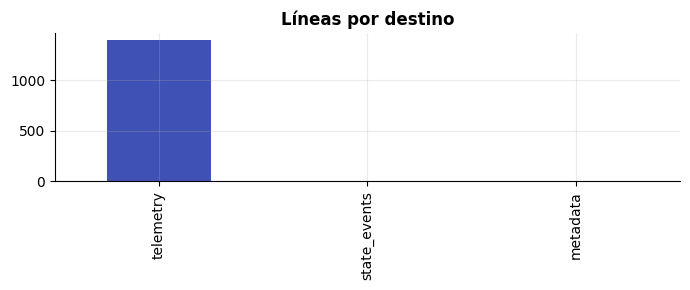

In [6]:
counts = pd.Series({"telemetry": len(telem_lines), "state_events": len(state_lines), "metadata": len(catalogo)})
counts.plot.bar(color="#3F51B5", figsize=(7, 3))
plt.title("Líneas por destino")
plt.tight_layout()


## 14. Validaciones

Cada `state_events` debe contener `value=0` o `value=1`.


In [7]:
import re

if state_lines:
    for line in state_lines[:5]:
        m = re.search(r"value=([0-9.]+)", line)
        val = float(m.group(1))
        assert val in {0.0, 1.0}, f"Bad value: {val}"
    print("State_events OK · ejemplo:", state_lines[0])
else:
    print("Sin transiciones de estado en este sample (todas las filas iguales).")


Sin transiciones de estado en este sample (todas las filas iguales).


## 15. Errores comunes

1. **No emitir cambio inicial**: `diff()` en NaN omite el primer valor.
2. **Mismo timestamp dos veces**: dedup InfluxDB las descarta.
3. **Olvidar metadata**: rollups vacíos.


## 16. Ejercicios propuestos

1. Añade `vehicle_count` con `domain_id=traffic_cameras`.
2. Verifica que `Occupied=1` también va a `telemetry` (bool_presence).
3. Prueba a desactivar la metadata y observa qué falla.


## 17. Cómo se reutiliza con datos reales

El sensor real publica directamente; este ETL es solo para datasets públicos. Pero la **definición** de variables y metadata se mantiene.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `04_case_D_iaq_occupancy/03_features_confort_ocupacion.ipynb`.
- Documento web del caso: `docs/contracts/variable-catalog.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.
